# ViewCastLK — Exploratory Data Analysis

**What can be known about a Sri Lankan YouTube video before it is published,
and how much of its first-week viewership does that explain?**

This notebook answers that question and hands the answer to feature
engineering. It is not a data-quality report — `dataset_statistics.txt` covers
that. This looks for *patterns*.

---

## The methodological spine

One fact governs every analysis below:

> **Channel identity explains ~64% of the variance in log day-7 views.
> Everything else combined explains far less.**

That single fact invalidates the obvious way of doing this. If you group by
category and compare means, you are mostly comparing *which channels post in
which category*, not the effect of category. §4 shows this concretely,
where the raw category ranking **inverts** once channel is controlled for.

So the rule throughout:

| question | method |
|---|---|
| "does X matter?" | compare on **within-channel residuals** |
| "how big is the effect?" | report both raw and residual, and say when they disagree |
| "is it real?" | report cell counts and standard errors, not just means |

A **within-channel residual** is `log1p(views)` minus that channel's own mean
`log1p(views)`. It asks: *given this channel, did this video do better or worse
than that channel usually does?* That is the only version of the question a
pre-publication model can actually act on, because the channel is fixed at
prediction time.

## Target

`log1p(day-7 views)`. The raw target has a mean 16x its median and a maximum
four orders of magnitude above it; on the log scale skew is -0.13, near
symmetric. Day 7 is the primary horizon because it has the most labels
(70,466); §13 checks whether the findings hold at 14, 21 and 30 days.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

mpl.rcParams.update({
    "figure.figsize": (10, 5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 10,
})

from paths import dataset_path
DATA = dataset_path()
FIGS = Path("eda_figures"); FIGS.mkdir(exist_ok=True)

def save(name):
    plt.tight_layout(); plt.savefig(FIGS / f"{name}.png", bbox_inches="tight")

HORIZON = 7

## 1. Scope and preparation

Scope is **eligible** videos (live broadcasts and unparseable durations removed)
that have a **usable** day-7 label — an observation within 12 hours of the
168-hour mark. Anything else is not an observation of day-7 viewership.

`channel_resid` is added here and used for the rest of the notebook.

In [2]:
df = pd.read_parquet(DATA)

d = df[df.eligible & df[f"d{HORIZON}_usable"]].copy()
d["y"] = np.log1p(d[f"d{HORIZON}_views"])

# Within-channel residual: how this video did relative to its own channel.
ch_mean = d.groupby("channel_id").y.transform("mean")
ch_n    = d.groupby("channel_id").y.transform("size")
d["channel_resid"] = d.y - ch_mean
d["channel_n"] = ch_n

print(f"videos with a usable day-{HORIZON} label : {len(d):,}")
print(f"distinct channels                       : {d.channel_id.nunique():,}")
print(f"published                               : "
      f"{d.published_at.min():%Y-%m-%d} to {d.published_at.max():%Y-%m-%d}")
print(f"\nlog1p(views): mean {d.y.mean():.2f}, sd {d.y.std():.2f}, "
      f"skew {d.y.skew():.2f}")
print(f"raw views   : median {d[f'd{HORIZON}_views'].median():,.0f}, "
      f"mean {d[f'd{HORIZON}_views'].mean():,.0f}, "
      f"max {d[f'd{HORIZON}_views'].max():,.0f}")

videos with a usable day-7 label : 70,466
distinct channels                       : 2,251
published                               : 2026-07-16 to 2026-09-07

log1p(views): mean 6.97, sd 2.59, skew -0.13
raw views   : median 1,169, mean 19,084, max 17,366,520


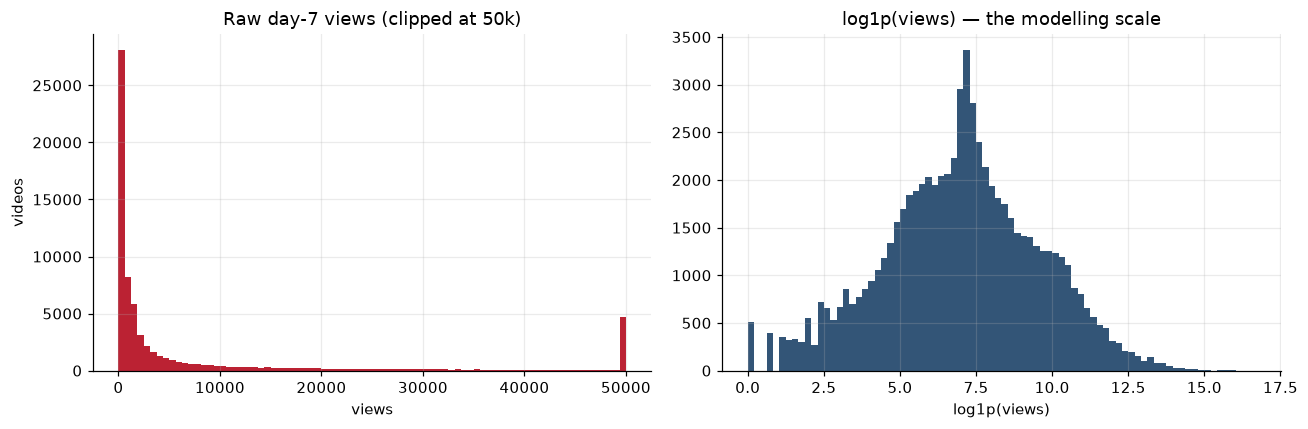

share of all day-7 views held by the top:
    0.1% of videos :  14.8%
    1.0% of videos :  43.3%
    5.0% of videos :  72.2%
   10.0% of videos :  84.1%


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(d[f"d{HORIZON}_views"].clip(upper=50_000), bins=80, color="#b23")
ax[0].set(title=f"Raw day-{HORIZON} views (clipped at 50k)", xlabel="views",
          ylabel="videos")
ax[1].hist(d.y, bins=80, color="#357")
ax[1].set(title="log1p(views) — the modelling scale", xlabel="log1p(views)")
save("01_target_distribution"); plt.show()

q = d[f"d{HORIZON}_views"]
print("share of all day-7 views held by the top:")
for k in (0.001, 0.01, 0.05, 0.10):
    print(f"  {k:>6.1%} of videos : {q.nlargest(int(len(q)*k)).sum()/q.sum():>6.1%}")

## 2. Variance decomposition — how much can anything explain?

For a grouping *g*, the share of variance its group means explain is

$$R^2_g = 1 - \frac{\mathrm{Var}(y - \bar{y}_g)}{\mathrm{Var}(y)}$$

This is an **upper bound** on what a model using only that variable could
achieve — it assumes you predict each group's mean perfectly.

Read the result as a budget: it tells you where predictive power can possibly
come from, before any modelling.

In [4]:
def var_explained(frame, col, target="y"):
    g = frame.groupby(col)[target].transform("mean")
    return 1 - (frame[target] - g).var() / frame[target].var()

d["subs_band"] = pd.cut(d.ch_subs_at_publish,
                        [0, 1e3, 1e4, 1e5, 1e6, np.inf],
                        labels=["<1K", "1K-10K", "10K-100K", "100K-1M", "1M+"])
d["dur_band"] = pd.cut(d.duration_seconds,
                       [0, 60, 180, 600, 1800, np.inf],
                       labels=["<=60s", "1-3m", "3-10m", "10-30m", "30m+"])

rows = []
for col in ["channel_id", "category_name", "subs_band", "dur_band",
            "publish_hour_slt", "publish_dow_slt", "title_script",
            "is_short", "definition", "made_for_kids", "default_audio_language",
            "publish_is_weekend", "channel_country"]:
    sub = d[d[col].notna()] if d[col].isna().any() else d
    rows.append({"variable": col, "levels": sub[col].nunique(),
                 "var_explained": var_explained(sub, col)})

vd = pd.DataFrame(rows).sort_values("var_explained", ascending=False)
vd["var_explained"] = vd.var_explained.round(4)
print(vd.to_string(index=False))

              variable  levels  var_explained
            channel_id    2251          0.635
             subs_band       5          0.225
         category_name      14          0.088
          title_script       4          0.037
default_audio_language      34          0.035
              dur_band       5          0.019
      publish_hour_slt      24          0.017
         made_for_kids       2          0.007
            definition       2          0.004
       publish_dow_slt       7          0.001
              is_short       2          0.001
       channel_country       3          0.000
    publish_is_weekend       2          0.000


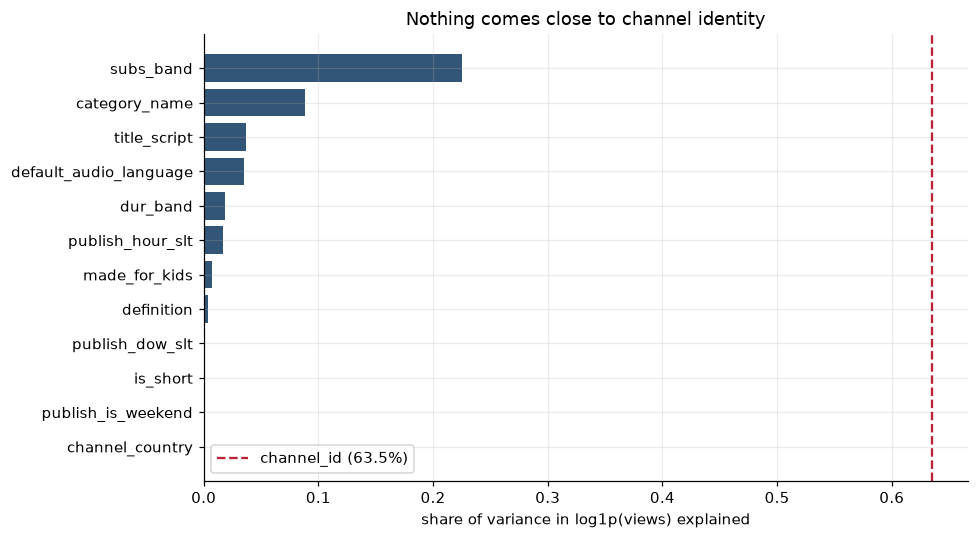

In [5]:
plot = vd[vd.variable != "channel_id"].sort_values("var_explained")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot.variable, plot.var_explained, color="#357")
ax.axvline(vd.loc[vd.variable == "channel_id", "var_explained"].iloc[0],
           color="#b23", ls="--",
           label=f"channel_id ({vd.loc[vd.variable=='channel_id','var_explained'].iloc[0]:.1%})")
ax.set(xlabel="share of variance in log1p(views) explained",
       title="Nothing comes close to channel identity")
ax.legend()
save("02_variance_explained"); plt.show()

### Reading this

`channel_id` has thousands of levels, so some of its apparent power is
overfitting — with enough groups you can explain anything. The honest
comparison is against a *permuted* channel label, done next.

Everything below `channel_id` is measured on few levels and is not inflated
this way.

In [6]:
rng = np.random.default_rng(0)
real = var_explained(d, "channel_id")
perm = []
for _ in range(5):
    tmp = d.copy()
    tmp["fake"] = rng.permutation(tmp.channel_id.values)
    perm.append(var_explained(tmp, "fake"))

print(f"channel_id, real        : {real:.4f}")
print(f"channel_id, shuffled    : {np.mean(perm):.4f}  "
      f"(this is the overfitting floor)")
print(f"genuine channel effect  : {real - np.mean(perm):.4f}")
print("\nSo channel identity really does carry most of the signal; the")
print("shuffled baseline shows only a small part is an artefact of group count.")

channel_id, real        : 0.6347
channel_id, shuffled    : 0.0325  (this is the overfitting floor)
genuine channel effect  : 0.6022

So channel identity really does carry most of the signal; the
shuffled baseline shows only a small part is an artefact of group count.


## 3. What is it about a channel that matters?

Channel identity dominates — but *identity* is not a usable feature for a new
channel. What measurable channel properties stand in for it?

In [7]:
ch = (d.groupby("channel_id")
        .agg(videos=("y", "size"), mean_y=("y", "mean"),
             subs=("ch_subs_at_publish", "median"),
             ch_age=("channel_age_days_at_publish", "median"),
             shorts=("is_short", "mean"),
             dur=("duration_seconds", "median"),
             cats=("category_name", "nunique"))
        .reset_index())
ch["posts_per_day"] = ch.videos / d.published_at.dt.date.nunique()
ch["log_subs"] = np.log1p(ch.subs)

print(f"channels: {len(ch):,}")
print(ch[["videos","subs","posts_per_day","mean_y"]].describe(
    percentiles=[.5, .9, .99]).to_string())

channels: 2,251
         videos           subs  posts_per_day    mean_y
count 2,251.000      2,251.000      2,251.000 2,251.000
mean     31.304    114,748.521          0.580     6.147
std     219.817    468,462.321          4.071     2.300
min       1.000          0.000          0.019     0.000
50%       8.000      8,930.000          0.148     6.087
90%      45.000    186,000.000          0.833     9.172
99%     264.500  1,817,500.000          4.898    11.641
max   7,821.000 11,000,000.000        144.833    14.543


Spearman correlation with channel mean log-views:

log_subs         0.633
posts_per_day    0.206
videos           0.206
ch_age           0.075
dur              0.061
shorts          -0.015
cats            -0.035


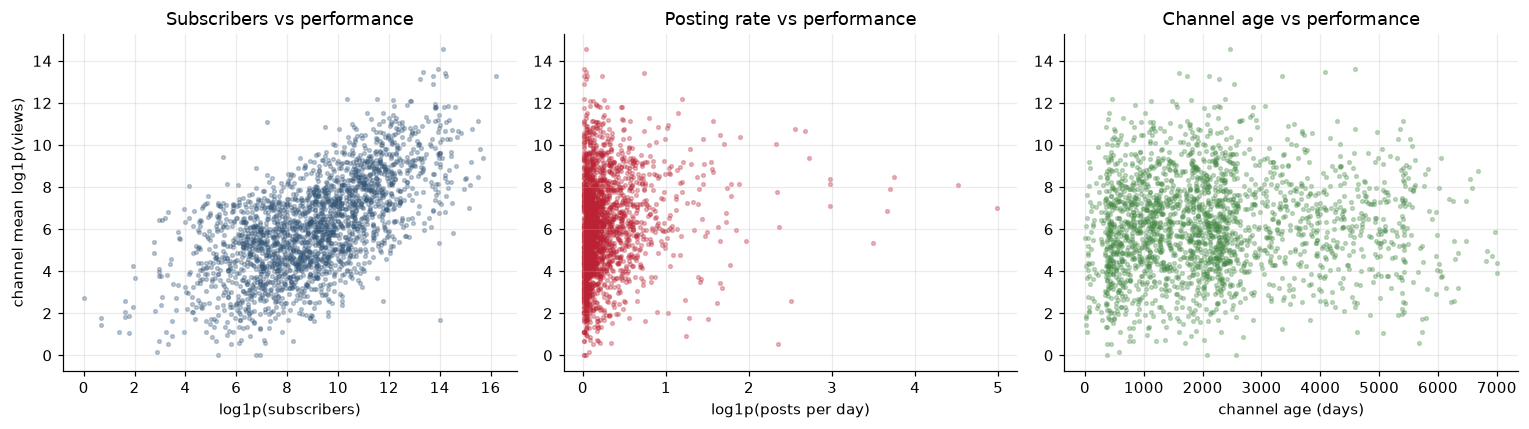

In [8]:
num = ["log_subs", "posts_per_day", "ch_age", "shorts", "dur", "cats", "videos"]
corr = ch[num + ["mean_y"]].corr(method="spearman")["mean_y"].drop("mean_y")
print("Spearman correlation with channel mean log-views:\n")
print(corr.sort_values(ascending=False).to_string())

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].scatter(ch.log_subs, ch.mean_y, s=6, alpha=.3, color="#357")
ax[0].set(xlabel="log1p(subscribers)", ylabel="channel mean log1p(views)",
          title="Subscribers vs performance")
ax[1].scatter(np.log1p(ch.posts_per_day), ch.mean_y, s=6, alpha=.3, color="#b23")
ax[1].set(xlabel="log1p(posts per day)", title="Posting rate vs performance")
ax[2].scatter(ch.ch_age, ch.mean_y, s=6, alpha=.3, color="#484")
ax[2].set(xlabel="channel age (days)", title="Channel age vs performance")
save("03_channel_properties"); plt.show()

### The dilution question

The largest channel posts ~150 clips a day. Does flooding the feed cost views
per video? This is testable: hold subscribers roughly constant and vary posting
rate.

In [9]:
band = pd.cut(ch.subs, [0, 1e4, 1e5, 1e6, np.inf],
              labels=["<10K", "10K-100K", "100K-1M", "1M+"])
rate = pd.qcut(ch.posts_per_day, 4, labels=["Q1 slowest", "Q2", "Q3", "Q4 fastest"],
               duplicates="drop")
piv = ch.assign(band=band, rate=rate).pivot_table(
    index="band", columns="rate", values="mean_y", aggfunc="mean", observed=True)
cnt = ch.assign(band=band, rate=rate).pivot_table(
    index="band", columns="rate", values="mean_y", aggfunc="size", observed=True)
print("channel mean log1p(views), by subscriber band x posting rate:\n")
print(piv.round(2).to_string())
print("\ncell counts:\n"); print(cnt.to_string())
print("\nIf posting faster diluted views, rows would fall left-to-right.")

channel mean log1p(views), by subscriber band x posting rate:

rate      Q1 slowest    Q2     Q3  Q4 fastest
band                                         
<10K           4.620 5.040  5.140       5.190
10K-100K       6.480 6.780  6.810       7.210
100K-1M        8.910 8.800  8.790       7.920
1M+            9.870 8.630 10.040       9.360

cell counts:

rate      Q1 slowest   Q2   Q3  Q4 fastest
band                                      
<10K             397  312  255         224
10K-100K         173  157  166         200
100K-1M           61   65   75          95
1M+                7    3   17          43

If posting faster diluted views, rows would fall left-to-right.


## 4. Category — where the raw view is actively misleading

This is the headline methodological result of the notebook.

In [10]:
raw = d.groupby("category_name").y.agg(["size", "mean"])
raw["raw_views"] = np.expm1(raw["mean"])

# Within-channel: only channels that actually post in more than one category
# can contribute -- for a single-category channel the comparison is empty.
multi = d.groupby("channel_id").category_name.nunique()
dm = d[d.channel_id.isin(multi[multi > 1].index)]

within = dm.groupby("category_name").channel_resid.agg(["size", "mean", "std"])
within["se"] = within["std"] / np.sqrt(within["size"])
within["ci95"] = 1.96 * within.se

cmp = raw[["size", "raw_views", "mean"]].join(
    within[["size", "mean", "ci95"]], lsuffix="_raw", rsuffix="_within")
cmp.columns = ["n_raw", "raw_views", "raw_logmean", "n_within",
               "within_effect", "ci95"]
cmp["raw_rank"] = cmp.raw_logmean.rank(ascending=False).astype(int)
cmp["within_rank"] = cmp.within_effect.rank(ascending=False).astype(int)
cmp["rank_shift"] = cmp.raw_rank - cmp.within_rank
print(cmp.sort_values("raw_rank").to_string())

                      n_raw  raw_views  raw_logmean  n_within  within_effect  ci95  raw_rank  within_rank  rank_shift
category_name                                                                                                        
Entertainment          8711  5,233.557        8.563      1026         -0.261 0.094         1           14         -13
Comedy                 1582  4,907.826        8.499       161          0.126 0.212         2            3          -1
People & Blogs         3905  1,960.395        7.581      2236         -0.014 0.068         3           10          -7
Sports                 1681  1,156.735        7.054       217          0.087 0.228         4            4           0
News & Politics       21805  1,120.345        7.022       141          1.781 0.260         5            1           4
Music                  4997    845.208        6.741       199          0.143 0.198         6            2           4
Autos & Vehicles       1742    794.648        6.679     

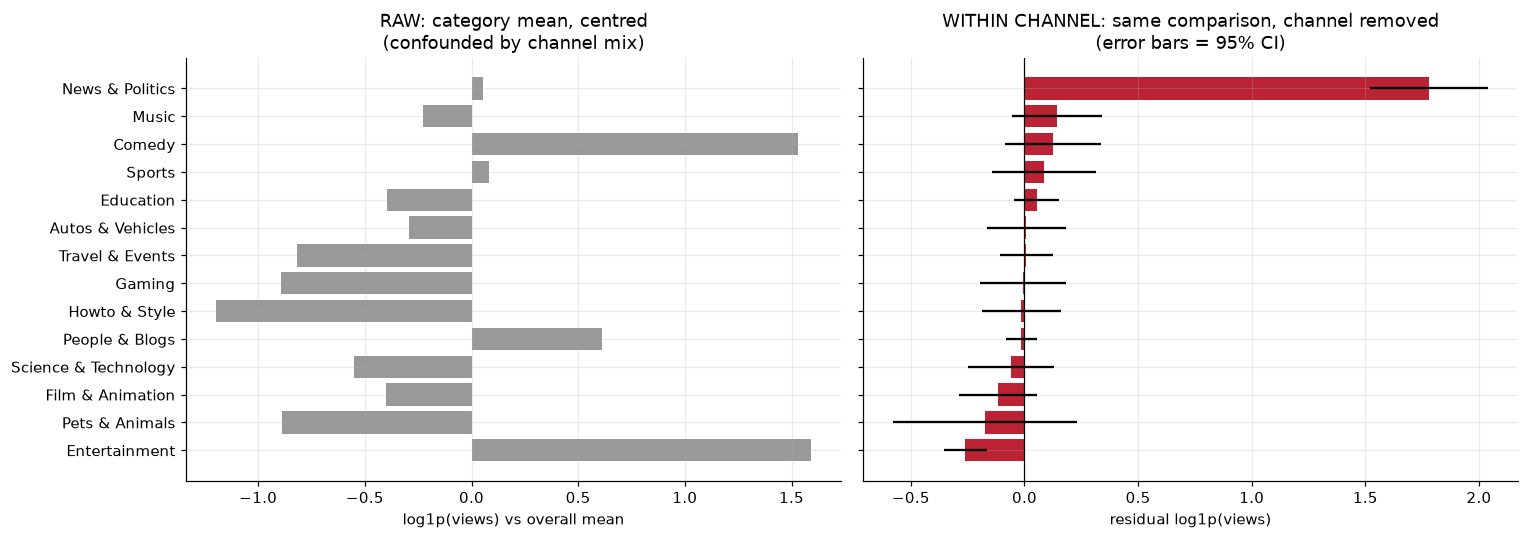

Categories whose rank moves most when channel is controlled:
                 raw_rank  within_rank  rank_shift  n_within
category_name                                               
Entertainment           1           14         -13      1026
People & Blogs          3           10          -7      2236
Howto & Style          14            9           5       227
Gaming                 13            8           5       358
News & Politics         5            1           4       141
Music                   6            2           4       199


In [11]:
o = cmp.sort_values("within_effect")
fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
ax[0].barh(o.index, o.raw_logmean - d.y.mean(), color="#999")
ax[0].set(title="RAW: category mean, centred\n(confounded by channel mix)",
          xlabel="log1p(views) vs overall mean")
ax[1].barh(o.index, o.within_effect, xerr=o.ci95, color="#b23")
ax[1].axvline(0, color="k", lw=.8)
ax[1].set(title="WITHIN CHANNEL: same comparison, channel removed\n"
                "(error bars = 95% CI)", xlabel="residual log1p(views)")
save("04_category_raw_vs_within"); plt.show()

print("Categories whose rank moves most when channel is controlled:")
print(cmp.reindex(cmp.rank_shift.abs().sort_values(ascending=False).index)
        [["raw_rank","within_rank","rank_shift","n_within"]].head(6).to_string())

### Caveat, stated plainly

The within-channel column rests only on channels that post across multiple
categories. Those channels may be unusual, and some cells are small — read the
confidence intervals and the `n_within` column before believing any single row.

Where `n_within` is small, the raw and within numbers disagreeing tells you the
category is **channel-bound** (only certain channels post it), which is itself
a finding: for those categories, category and channel are the same variable.

## 5. Timing — is there a best hour to publish?

The most commercially interesting question, and the most confounded: news
channels post on fixed schedules, so a raw hourly profile largely traces
*who* posts when.

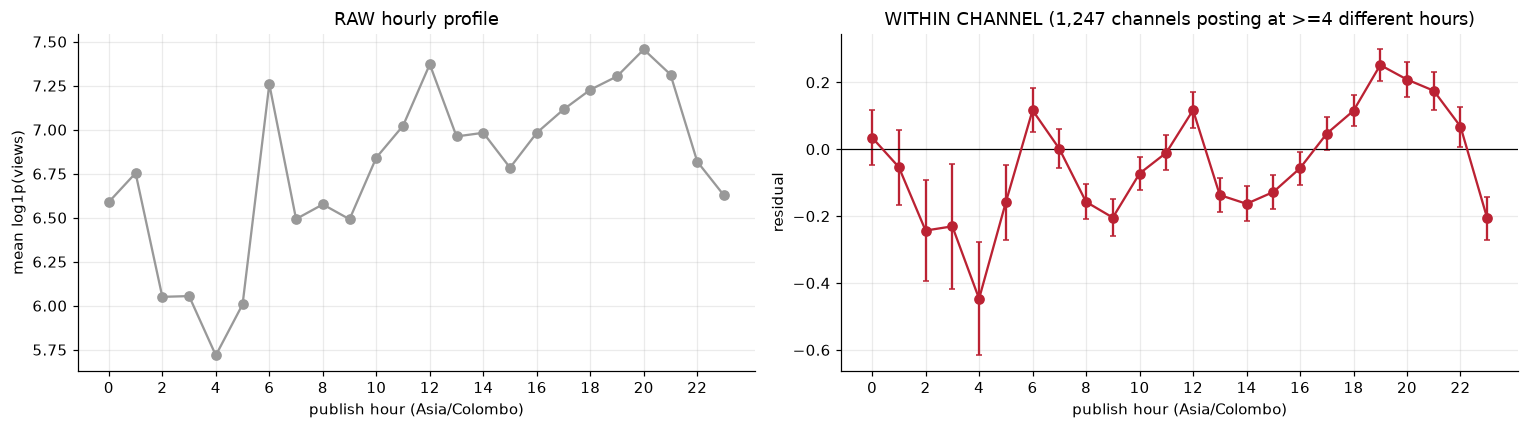

raw spread    (best-worst hour): 1.738 log units
within spread (best-worst hour): 0.699 log units
best hours within channel : [19, 20, 21]
worst hours within channel: [4, 2, 3]


In [12]:
by_hour_raw = d.groupby("publish_hour_slt").y.agg(["size", "mean"])

# Only channels that publish across several hours can inform an hour effect.
hspread = d.groupby("channel_id").publish_hour_slt.nunique()
dh = d[d.channel_id.isin(hspread[hspread >= 4].index)]
by_hour_within = dh.groupby("publish_hour_slt").channel_resid.agg(
    ["size", "mean", "std"])
by_hour_within["se"] = by_hour_within["std"] / np.sqrt(by_hour_within["size"])

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(by_hour_raw.index, by_hour_raw["mean"], marker="o", color="#999")
ax[0].set(title="RAW hourly profile", xlabel="publish hour (Asia/Colombo)",
          ylabel="mean log1p(views)", xticks=range(0, 24, 2))
ax[1].errorbar(by_hour_within.index, by_hour_within["mean"],
               yerr=1.96*by_hour_within.se, marker="o", color="#b23", capsize=2)
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title=f"WITHIN CHANNEL ({dh.channel_id.nunique():,} channels "
                f"posting at >=4 different hours)",
          xlabel="publish hour (Asia/Colombo)", ylabel="residual",
          xticks=range(0, 24, 2))
save("05_publish_hour"); plt.show()

sw = by_hour_within["mean"]
print(f"raw spread    (best-worst hour): {by_hour_raw['mean'].max()-by_hour_raw['mean'].min():.3f} log units")
print(f"within spread (best-worst hour): {sw.max()-sw.min():.3f} log units")
print(f"best hours within channel : {list(sw.nlargest(3).index)}")
print(f"worst hours within channel: {list(sw.nsmallest(3).index)}")

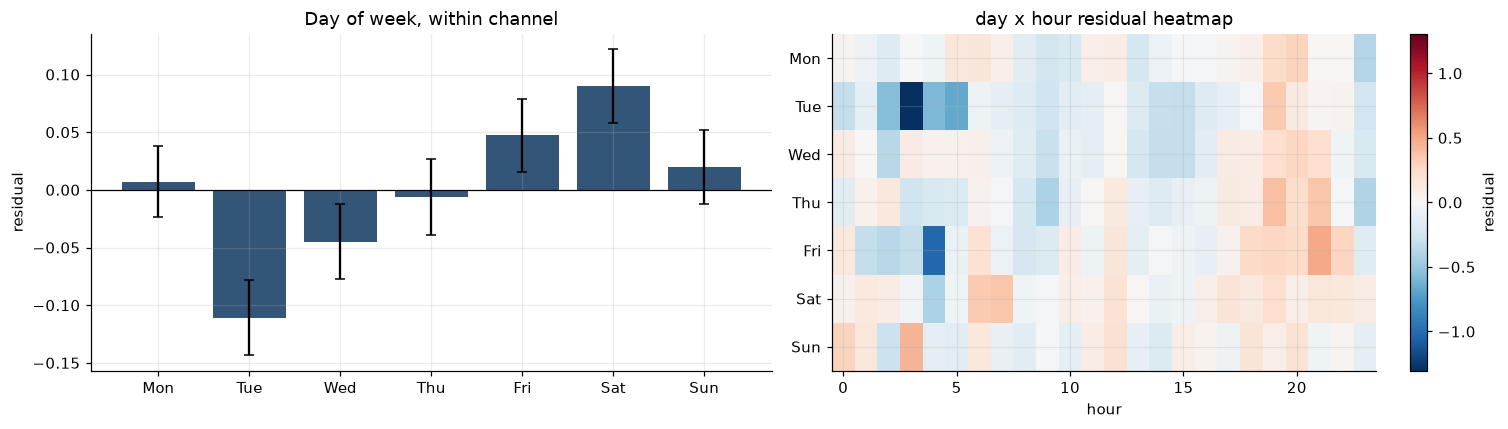

In [13]:
# Day of week, and the hour x weekend interaction.
dow = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
w = dh.groupby("publish_dow_slt").channel_resid.agg(["size","mean","std"])
w["se"] = w["std"]/np.sqrt(w["size"])
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar([dow[i] for i in w.index], w["mean"], yerr=1.96*w.se,
          color="#357", capsize=3)
ax[0].axhline(0, color="k", lw=.8); ax[0].set(title="Day of week, within channel",
                                              ylabel="residual")

hm = dh.pivot_table(index="publish_dow_slt", columns="publish_hour_slt",
                    values="channel_resid", aggfunc="mean")
im = ax[1].imshow(hm.values, aspect="auto", cmap="RdBu_r",
                  vmin=-np.abs(hm.values).max(), vmax=np.abs(hm.values).max())
ax[1].set(title="day x hour residual heatmap", xlabel="hour",
          yticks=range(7), yticklabels=dow)
plt.colorbar(im, ax=ax[1], label="residual")
save("06_dow_and_heatmap"); plt.show()

## 6. Duration and format

Shorts vs long-form is the most consequential format decision a creator makes.
Raw medians are nearly identical, which is suspicious — it usually means two
opposing effects cancelling.

RAW:
              n    median       mean
is_short                            
False     42341 1,123.000 16,010.199
True      28125 1,210.000 23,712.644

WITHIN CHANNEL (1,012 channels posting both):
              n   mean    sd
is_short                    
False     33477 -0.026 1.716
True      22097  0.039 1.537


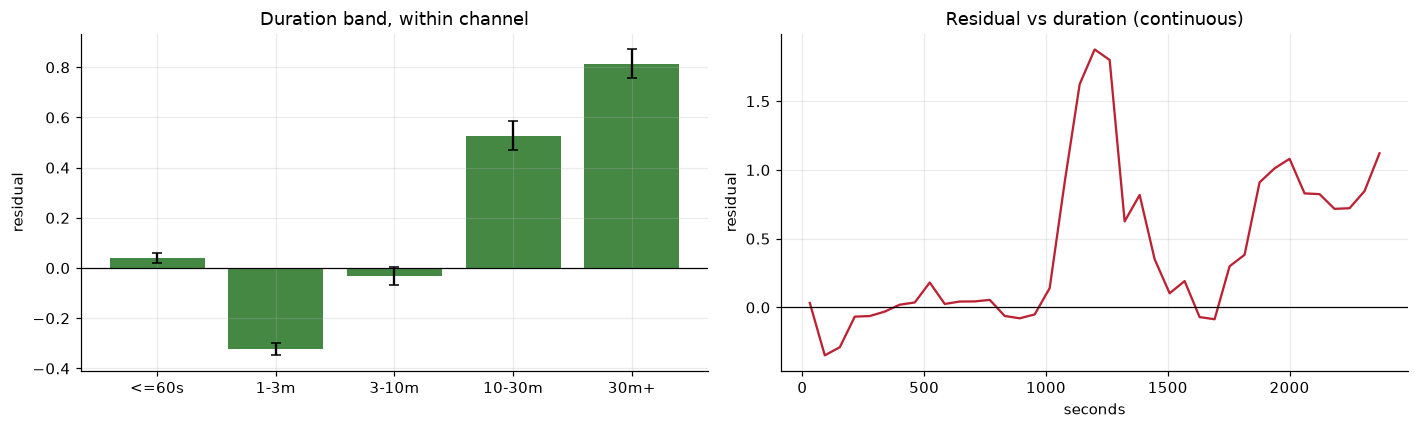

In [14]:
print("RAW:")
print(d.groupby("is_short")[f"d{HORIZON}_views"].agg(
    n="size", median="median", mean="mean").to_string())

fmt = d.groupby("channel_id").is_short.nunique()
dfm = d[d.channel_id.isin(fmt[fmt > 1].index)]
print(f"\nWITHIN CHANNEL ({dfm.channel_id.nunique():,} channels posting both):")
print(dfm.groupby("is_short").channel_resid.agg(
    n="size", mean="mean", sd="std").to_string())

t = dfm.groupby("dur_band", observed=True).channel_resid.agg(["size","mean","std"])
t["se"] = t["std"]/np.sqrt(t["size"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].bar(t.index.astype(str), t["mean"], yerr=1.96*t.se, color="#484", capsize=3)
ax[0].axhline(0, color="k", lw=.8)
ax[0].set(title="Duration band, within channel", ylabel="residual")

s = dfm[dfm.duration_seconds < 2400]
bins = np.linspace(0, 2400, 40)
mids = (bins[:-1]+bins[1:])/2
prof = s.groupby(pd.cut(s.duration_seconds, bins),
                 observed=True).channel_resid.mean()
ax[1].plot(mids[:len(prof)], prof.values, color="#b23")
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title="Residual vs duration (continuous)", xlabel="seconds",
          ylabel="residual")
save("07_duration"); plt.show()

## 7. Title features

Everything here is knowable before publication and is cheap to act on, so even
small effects are practically useful — a creator can rewrite a title.

In [15]:
title_feats = ["title_length", "title_word_count", "title_upper_ratio",
               "tag_count", "description_length"]
flags = ["title_has_number", "title_has_question", "title_has_exclaim",
         "caption", "made_for_kids"]

print("Spearman correlation with WITHIN-CHANNEL residual:\n")
print(d[title_feats + ["channel_resid"]].corr(method="spearman")
        ["channel_resid"].drop("channel_resid").sort_values(
            key=abs, ascending=False).to_string())

print("\nBinary flags — mean residual by value:\n")
for f in flags:
    if d[f].notna().any():
        g = d.groupby(f).channel_resid.agg(["size", "mean"])
        if len(g) == 2:
            diff = g["mean"].iloc[1] - g["mean"].iloc[0]
            print(f"  {f:22} effect {diff:+.3f}   "
                  f"(n={g['size'].iloc[1]:,} true / {g['size'].iloc[0]:,} false)")

Spearman correlation with WITHIN-CHANNEL residual:

title_upper_ratio     0.059
title_word_count      0.033
title_length          0.022
description_length    0.011
tag_count            -0.007

Binary flags — mean residual by value:

  title_has_number       effect +0.218   (n=21,719 true / 48,747 false)
  title_has_question     effect -0.155   (n=4,275 true / 66,191 false)
  title_has_exclaim      effect -0.138   (n=4,872 true / 65,594 false)
  caption                effect +0.179   (n=140 true / 70,326 false)
  made_for_kids          effect -0.178   (n=403 true / 70,063 false)


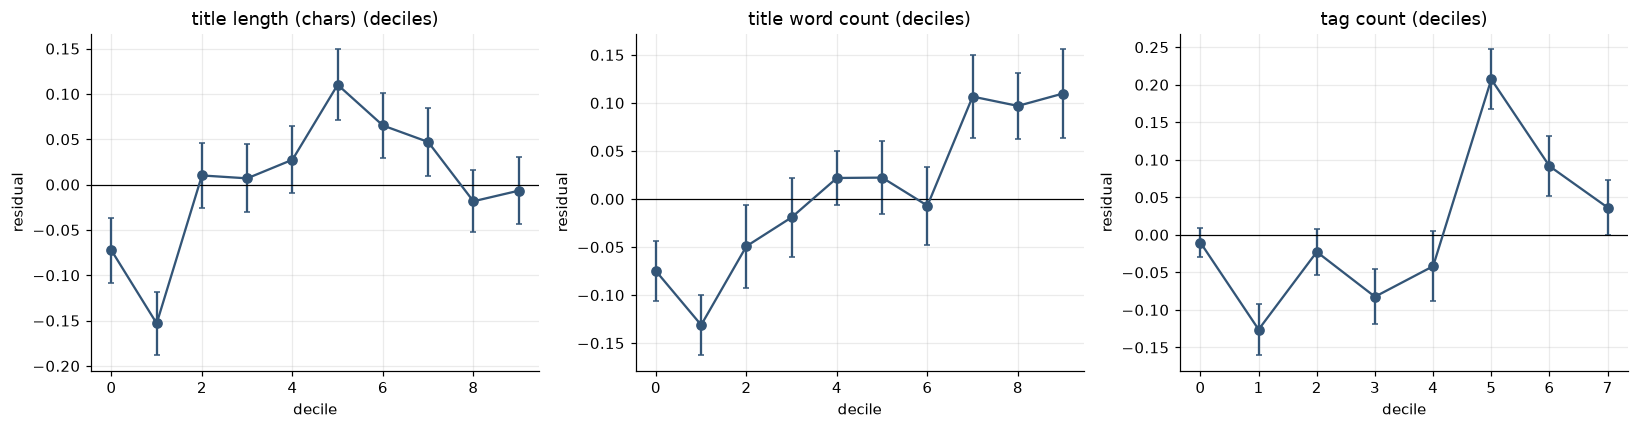

title_script, within channel (channels using >1 script):
                    n   mean
title_script                
latin_script    10007 -0.017
mixed_script       17  0.443
sinhala_script  37745  0.003
tamil_script     1155  0.031


In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, f, lab in zip(ax, ["title_length", "title_word_count", "tag_count"],
                     ["title length (chars)", "title word count", "tag count"]):
    b = pd.qcut(d[f], 10, duplicates="drop")
    g = d.groupby(b, observed=True).channel_resid.agg(["mean", "size", "std"])
    g["se"] = g["std"]/np.sqrt(g["size"])
    a.errorbar(range(len(g)), g["mean"], yerr=1.96*g.se, marker="o",
               color="#357", capsize=2)
    a.axhline(0, color="k", lw=.8)
    a.set(title=f"{lab} (deciles)", xlabel="decile", ylabel="residual")
save("08_title_features"); plt.show()

# Script is largely an audience-size proxy; check it within channel too.
sc = d.groupby("channel_id").title_script.nunique()
ds = d[d.channel_id.isin(sc[sc > 1].index)]
print("title_script, within channel (channels using >1 script):")
print(ds.groupby("title_script").channel_resid.agg(
    n="size", mean="mean").to_string())

## 8. Tag mining

Tags are the richest pre-publication text field. 29% of videos have none —
which is itself a signal worth testing before treating it as missing data.

In [17]:
print("Having ANY tags at all, within channel:")
d["has_tags"] = d.tags.notna()
ht = d.groupby("channel_id").has_tags.nunique()
dt = d[d.channel_id.isin(ht[ht > 1].index)]
print(dt.groupby("has_tags").channel_resid.agg(n="size", mean="mean").to_string())

# Per-tag lift, measured on residuals so a tag cannot win by belonging to a
# large channel.
ex = d[d.tags.notna()][["tags", "channel_resid"]].copy()
ex["tag"] = ex.tags.str.lower().str.split("|")
ex = ex.explode("tag")
ex["tag"] = ex.tag.str.strip()
ex = ex[ex.tag.str.len() > 1]

tg = ex.groupby("tag").channel_resid.agg(["size", "mean", "std"])
tg = tg[tg["size"] >= 100]
tg["se"] = tg["std"]/np.sqrt(tg["size"])
tg["t"] = tg["mean"]/tg.se
print(f"\n{len(tg):,} tags used on >=100 videos\n")
print("STRONGEST POSITIVE (by t-statistic):")
print(tg.nlargest(15, "t")[["size", "mean", "t"]].to_string())
print("\nSTRONGEST NEGATIVE:")
print(tg.nsmallest(15, "t")[["size", "mean", "t"]].to_string())

Having ANY tags at all, within channel:
              n   mean
has_tags              
False      8360  0.042
True      16767 -0.021



1,068 tags used on >=100 videos

STRONGEST POSITIVE (by t-statistic):
                      size  mean       t
tag                                     
hiru news today live   171 4.012 114.180
hiru news yesterday    173 3.977  89.602
la voz                 138 2.243  41.526
newshub                138 2.243  41.526
newsi                  138 2.243  41.526
ranjan new recording   138 2.243  41.526
ranjan ramanayaka      138 2.243  41.526
siyatha news 12pm      138 2.243  41.526
ranjan                 139 2.211  35.331
itn news               109 2.813  34.837
news from sri lanka    173 1.911  21.852
නිවුස් ෆස්ට්           173 1.911  21.852
සජීවි ප්‍රවෘත්ති       173 1.911  21.852
සිරස ප්‍රවෘත්ති        173 1.911  21.852
sri lanka trending     180 1.884  20.812

STRONGEST NEGATIVE:
                      size   mean       t
tag                                      
swarnavahini youtube   104 -1.470 -12.311
rathu ira              113 -1.864 -11.965
tharu adare           1997 -0.326  -9.339
h

In [18]:
# Association mining: which tag PAIRS co-occur, and do pairs beat their parts?
from itertools import combinations
from collections import Counter

top_tags = set(tg.nlargest(300, "size").index)
sets = (d[d.tags.notna()].tags.str.lower().str.split("|")
          .apply(lambda ts: {t.strip() for t in ts} & top_tags))
pairs = Counter()
for s in sets:
    if 1 < len(s) <= 25:
        pairs.update(combinations(sorted(s), 2))

rows = []
resid = d[d.tags.notna()].channel_resid.values
for (a, b), n in pairs.most_common(400):
    mask = sets.apply(lambda s: a in s and b in s).values
    if mask.sum() >= 50:
        rows.append({"tag_a": a, "tag_b": b, "n": int(mask.sum()),
                     "pair_effect": resid[mask].mean(),
                     "a_alone": tg.loc[a, "mean"] if a in tg.index else np.nan,
                     "b_alone": tg.loc[b, "mean"] if b in tg.index else np.nan})
ar = pd.DataFrame(rows)
if len(ar):
    ar["synergy"] = ar.pair_effect - ar[["a_alone", "b_alone"]].max(axis=1)
    print("Tag pairs that beat either tag alone (positive synergy):\n")
    print(ar.nlargest(12, "synergy").to_string(index=False))
else:
    print("no tag pair reached the support threshold")

Tag pairs that beat either tag alone (positive synergy):

        tag_a              tag_b    n  pair_effect  a_alone  b_alone  synergy
breaking news        sirasa news 1969        0.083   -0.043   -0.058    0.126
  sirasa news     sri lanka news 2160        0.076   -0.058   -0.008    0.084
  sirasa news          sri lanka 1969        0.083   -0.058    0.007    0.076
 english news          sri lanka 2005        0.080   -0.053    0.007    0.073
  latest news         today news 4998        0.003   -0.051   -0.058    0.055
  latest news         news today 4916        0.005   -0.051   -0.047    0.052
  derana news        latest news 4882        0.000   -0.060   -0.051    0.051
breaking news          sri lanka 3575        0.038   -0.043    0.007    0.032
breaking news sri lanka politics 1973        0.081   -0.043    0.050    0.031
    sri lanka sri lanka politics 1971        0.079    0.007    0.050    0.029
    sri lanka   sri lanka sports 1985        0.089    0.007    0.063    0.026
  sira

## 9. Posting cadence and self-cannibalisation

In §4 the category inversion was explained by a *mechanism*: high-volume news
channels post many near-identical clips a day and split a fixed audience across
them. That was an assertion. This section tests it directly.

The question a creator would ask: **does publishing another video soon after
this one cost it views?**

Two things to be careful about:

* Gaps must be computed over **every** eligible upload by that channel, not
  only the labelled ones. Using labelled videos alone would invent gaps of days
  where the channel actually posted hourly.
* Gap and channel are entangled — fast-posting channels have small gaps by
  definition — so, as everywhere else, the effect is measured on
  **within-channel residuals**.

In [19]:
# Neighbour structure from the FULL eligible set, then joined back to the
# labelled subset. Restricting to labelled videos first would fabricate gaps.
allv = df[df.eligible][["video_id", "channel_id", "published_at"]].copy()
allv = allv.sort_values(["channel_id", "published_at"])

grp = allv.groupby("channel_id").published_at
allv["gap_prev_h"] = grp.diff().dt.total_seconds() / 3600
allv["gap_next_h"] = (grp.shift(-1) - allv.published_at).dt.total_seconds() / 3600

# How crowded is this video's own channel around its publication?
ts = allv.set_index("published_at")
def crowd(g, hours):
    return (g.rolling(f"{hours}h", closed="both").video_id.count() - 1)
allv["same_ch_24h_before"] = (
    ts.groupby("channel_id", group_keys=False)
      .apply(lambda g: crowd(g, 24)).values)

d = d.merge(allv[["video_id", "gap_prev_h", "gap_next_h",
                  "same_ch_24h_before"]], on="video_id", how="left")

print("gap since the channel's previous upload (hours):")
print(d.gap_prev_h.describe(percentiles=[.1, .25, .5, .75, .9]).to_string())
print(f"\nvideos with a previous upload < 1h earlier: "
      f"{(d.gap_prev_h < 1).mean():.1%}")
print(f"same-channel uploads in the 24h before     : "
      f"median {d.same_ch_24h_before.median():.0f}, "
      f"max {d.same_ch_24h_before.max():.0f}")

gap since the channel's previous upload (hours):
count   70,062.000
mean        27.497
std         82.319
min          0.000
10%          0.017
25%          0.154
50%          1.647
75%         23.233
90%         65.475
max      1,494.427

videos with a previous upload < 1h earlier: 46.0%
same-channel uploads in the 24h before     : median 4, max 211


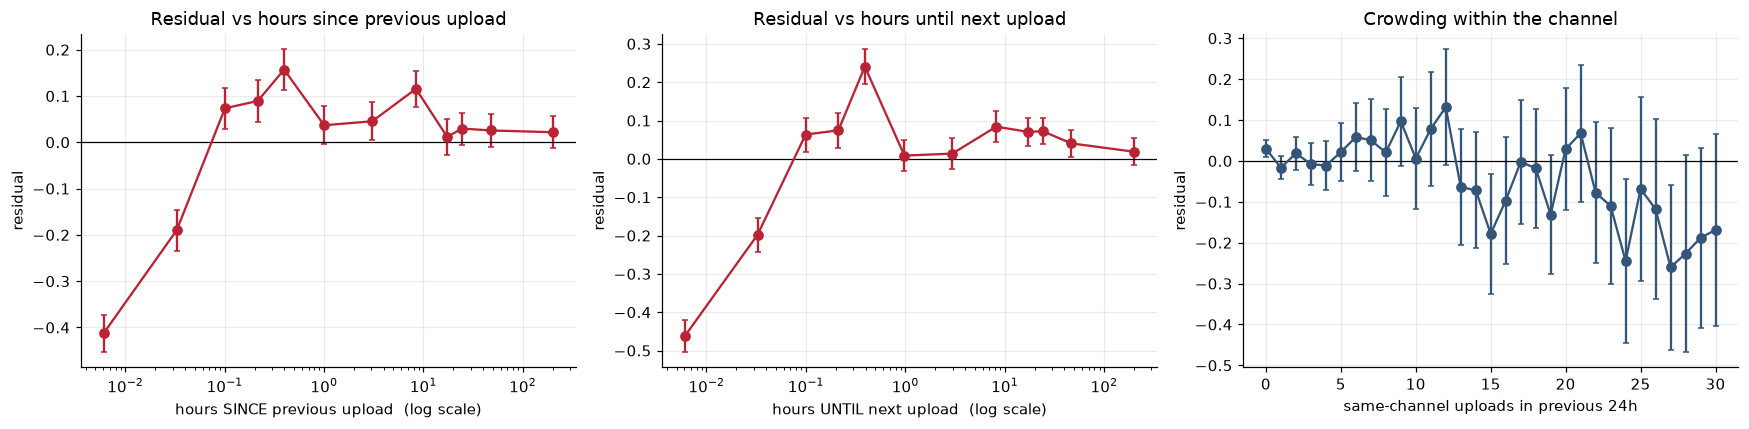

Spearman correlation with within-channel residual:
  gap_prev_h             +0.084   (n=70,062)
  gap_next_h             +0.091   (n=69,460)
  same_ch_24h_before     -0.055   (n=70,466)


In [20]:
# Effect of the gap BEFORE (how long the channel waited) and the gap AFTER
# (how quickly it followed up). The second is the cannibalisation test proper:
# what follows a video cannot have caused its own publication, so a negative
# effect there is harder to explain away as scheduling.
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for a, col, lab in [(ax[0], "gap_prev_h", "hours SINCE previous upload"),
                    (ax[1], "gap_next_h", "hours UNTIL next upload")]:
    s = d[d[col].between(0, 24 * 14)]
    b = pd.qcut(s[col], 12, duplicates="drop")
    g = s.groupby(b, observed=True).channel_resid.agg(["size", "mean", "std"])
    g["se"] = g["std"] / np.sqrt(g["size"])
    mids = [iv.mid for iv in g.index]
    a.errorbar(mids, g["mean"], yerr=1.96 * g.se, marker="o", capsize=2,
               color="#b23")
    a.axhline(0, color="k", lw=.8); a.set_xscale("log")
    a.set(xlabel=lab + "  (log scale)", ylabel="residual",
          title=f"Residual vs {lab.lower()}")

s = d[d.same_ch_24h_before <= 30]
g = s.groupby("same_ch_24h_before").channel_resid.agg(["size", "mean", "std"])
g = g[g["size"] >= 30]; g["se"] = g["std"] / np.sqrt(g["size"])
ax[2].errorbar(g.index, g["mean"], yerr=1.96 * g.se, marker="o", capsize=2,
               color="#357")
ax[2].axhline(0, color="k", lw=.8)
ax[2].set(xlabel="same-channel uploads in previous 24h", ylabel="residual",
          title="Crowding within the channel")
save("14_cadence"); plt.show()

print("Spearman correlation with within-channel residual:")
for c in ["gap_prev_h", "gap_next_h", "same_ch_24h_before"]:
    s = d[[c, "channel_resid"]].dropna()
    print(f"  {c:22} {s.corr(method='spearman').iloc[0,1]:+.3f}   (n={len(s):,})")

In [21]:
# Does cadence explain the category inversion? If the news effect is really
# volume, then controlling for crowding should shrink it.
band = pd.cut(d.same_ch_24h_before, [-1, 0, 2, 5, 10, 1e9],
              labels=["0", "1-2", "3-5", "6-10", "10+"])
piv = d.assign(crowd=band).pivot_table(
    index="category_name", columns="crowd", values="channel_resid",
    aggfunc="mean", observed=True)
cnt = d.assign(crowd=band).pivot_table(
    index="category_name", columns="crowd", values="channel_resid",
    aggfunc="size", observed=True)
print("residual by category x same-channel crowding (n>=50 only):\n")
print(piv.where(cnt >= 50).round(2).to_string())
print("\ncounts:\n"); print(cnt.fillna(0).astype(int).to_string())

print("\nWithin the busiest channels, is the news advantage still there?")
busy = d[d.same_ch_24h_before >= 10]
print(busy.groupby("category_name").channel_resid.agg(["size", "mean"])
        .query("size >= 100").sort_values("mean", ascending=False)
        .round(3).to_string())

residual by category x same-channel crowding (n>=50 only):

crowd                     0    1-2    3-5   6-10    10+
category_name                                          
Autos & Vehicles      0.090 -0.080 -0.020  0.110 -0.260
Comedy               -0.040  0.090 -0.040  0.030    NaN
Education             0.040  0.010 -0.020 -0.010 -0.070
Entertainment         0.080 -0.100 -0.030  0.030 -0.040
Film & Animation     -0.030  0.070  0.040 -0.180    NaN
Gaming                0.030 -0.030  0.030    NaN    NaN
Howto & Style        -0.050  0.060  0.020  0.170 -0.240
Music                 0.020  0.010 -0.100  0.070  0.090
News & Politics       0.180  0.100  0.040  0.060 -0.000
People & Blogs        0.020 -0.040 -0.030    NaN -0.020
Pets & Animals       -0.060  0.010  0.030  0.170 -0.690
Science & Technology  0.060 -0.070 -0.260    NaN    NaN
Sports                0.110 -0.030  0.120 -0.100 -0.370
Travel & Events       0.020 -0.020  0.080  0.070 -0.420

counts:

crowd                    0   1-2  

                   size   mean
category_name                 
Music               410  0.091
News & Politics   18923 -0.000
People & Blogs     1901 -0.015
Entertainment      5937 -0.036
Education          1249 -0.069
Autos & Vehicles    102 -0.152
Sports              113 -0.294
Travel & Events     273 -0.460
Pets & Animals      100 -0.478


## 10. Segmented analysis — do the effects hold everywhere?

Everything so far reports one number per feature, averaged over the whole
corpus. That hides the most useful kind of finding: an effect that is strong in
one segment and absent or reversed in another.

A single "shorts effect" is only meaningful if shorts behave the same way for a
500-subscriber cooking channel and a 3-million-subscriber news channel. They
almost certainly do not.

This section slices by **category**, by **channel size band**, and by both at
once, then scans for effects that differ most between segments. Every cell
carries its own `n` — with 14 categories x 5 size bands, some cells are far too
small to read.

=== residual by CATEGORY x SIZE BAND (mean) ===

subs_band               <1K  1K-10K  10K-100K  100K-1M    1M+
category_name                                                
Autos & Vehicles      0.000   0.000    -0.010    0.000 -0.280
Comedy                0.050   0.140     0.020   -0.070 -0.030
Education            -0.010   0.010    -0.020    0.040 -0.000
Entertainment         0.030  -0.130    -0.060   -0.010 -0.030
Film & Animation     -0.000  -0.060    -0.020    0.000 -0.000
Gaming               -0.000   0.010    -0.010    0.010    NaN
Howto & Style        -0.020   0.000     0.000    0.000  0.000
Music                 0.010  -0.000     0.010   -0.000  0.030
News & Politics       0.010  -0.020     0.020    0.000  0.020
People & Blogs        0.020  -0.060     0.050    0.010 -0.020
Pets & Animals        0.010  -0.030     0.000    0.090    NaN
Science & Technology  0.040   0.000    -0.010   -0.020 -0.010
Sports               -0.070   0.040     0.010    0.010  0.000
Travel & Events      

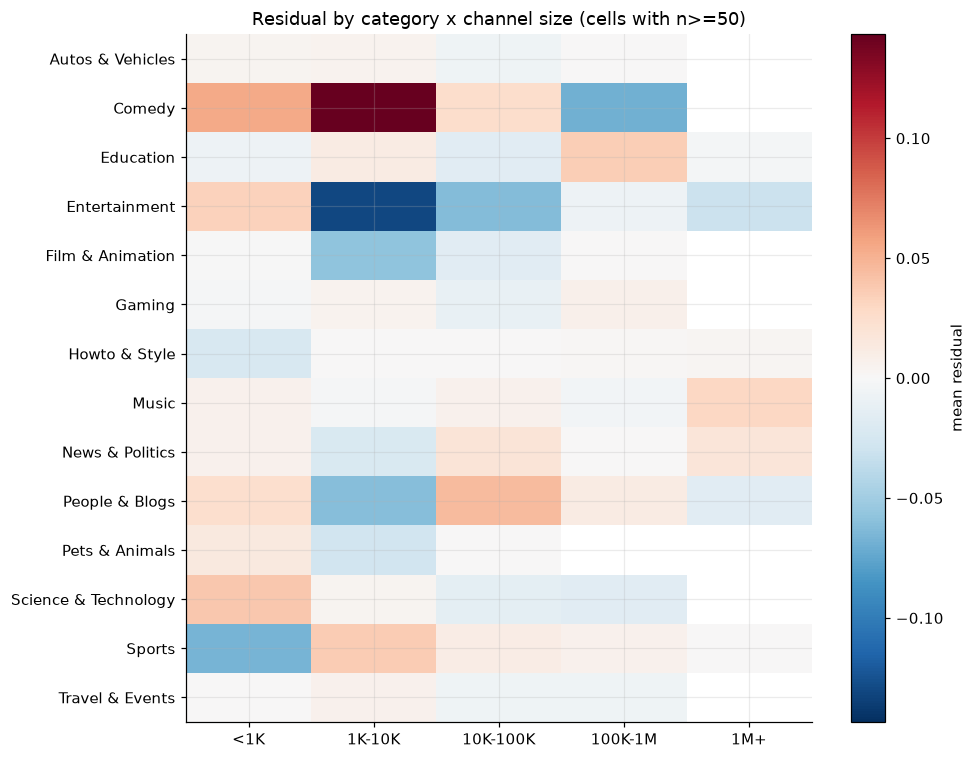

In [22]:
def seg_table(frame, seg, value="channel_resid", min_n=50):
    # Mean residual per segment, with the counts needed to judge it.
    g = frame.groupby(seg, observed=True)[value].agg(["size", "mean", "std"])
    g["se"] = g["std"] / np.sqrt(g["size"])
    g["ci95"] = 1.96 * g.se
    g["reliable"] = g["size"] >= min_n
    return g.drop(columns="std").sort_values("mean", ascending=False)

print("=== residual by CATEGORY x SIZE BAND (mean) ===\n")
piv = d.pivot_table(index="category_name", columns="subs_band",
                    values="channel_resid", aggfunc="mean", observed=True)
cnt = d.pivot_table(index="category_name", columns="subs_band",
                    values="channel_resid", aggfunc="size", observed=True)
print(piv.round(2).to_string())
print("\n=== cell counts (read nothing where n < 50) ===\n")
print(cnt.fillna(0).astype(int).to_string())

fig, ax = plt.subplots(figsize=(9, 7))
masked = piv.where(cnt >= 50)
im = ax.imshow(masked.values, cmap="RdBu_r", aspect="auto",
               vmin=-np.nanmax(np.abs(masked.values)),
               vmax=np.nanmax(np.abs(masked.values)))
ax.set(xticks=range(len(piv.columns)), xticklabels=piv.columns,
       yticks=range(len(piv.index)), yticklabels=piv.index,
       title="Residual by category x channel size (cells with n>=50)")
plt.colorbar(im, ax=ax, label="mean residual")
save("11_category_x_size"); plt.show()

In [23]:
# How an effect varies ACROSS segments. Each effect is a single number
# recomputed inside every segment, so the spread across segments shows
# whether the global figure is a real constant or an average of opposites.

def shorts_effect(f):
    a, b = f[f.is_short], f[~f.is_short]
    if len(a) < 30 or len(b) < 30:
        return np.nan
    return a.channel_resid.mean() - b.channel_resid.mean()

def hour_spread(f):
    g = f.groupby("publish_hour_slt").channel_resid.agg(["size", "mean"])
    g = g[g["size"] >= 20]
    return g["mean"].max() - g["mean"].min() if len(g) >= 6 else np.nan

def corr_with(f, col):
    s = f[[col, "channel_resid"]].dropna()
    return s.corr(method="spearman").iloc[0, 1] if len(s) >= 50 else np.nan

def effect_profile(f):
    return pd.Series({
        "n": len(f),
        "shorts_effect": shorts_effect(f),
        "hour_spread": hour_spread(f),
        "corr_title_len": corr_with(f, "title_length"),
        "corr_tag_count": corr_with(f, "tag_count"),
        "corr_duration": corr_with(f, "duration_seconds"),
        "weekend_effect": (f[f.publish_is_weekend].channel_resid.mean()
                           - f[~f.publish_is_weekend].channel_resid.mean()),
    })

print("=== EFFECTS WITHIN EACH CATEGORY ===\n")
by_cat = d.groupby("category_name", observed=True).apply(
    effect_profile, include_groups=False)
print(by_cat[by_cat.n >= 200].round(3).to_string())

print("\n=== EFFECTS WITHIN EACH CHANNEL SIZE BAND ===\n")
by_size = d.groupby("subs_band", observed=True).apply(
    effect_profile, include_groups=False)
print(by_size.round(3).to_string())

print("\nGLOBAL, for comparison:")
print(effect_profile(d).round(3).to_string())

=== EFFECTS WITHIN EACH CATEGORY ===



                              n  shorts_effect  hour_spread  corr_title_len  corr_tag_count  corr_duration  weekend_effect
category_name                                                                                                             
Autos & Vehicles      1,742.000          0.304        0.508          -0.000           0.030         -0.149          -0.066
Comedy                1,582.000          0.254        1.024          -0.005           0.003         -0.067           0.061
Education             9,813.000          0.156        0.385           0.019          -0.028         -0.036           0.052
Entertainment         8,711.000         -0.207        1.681           0.066           0.157          0.198          -0.079
Film & Animation      1,514.000         -0.085        0.849           0.023          -0.049          0.020          -0.022
Gaming                3,440.000          0.438        0.630          -0.023          -0.043         -0.104          -0.018
Howto & Style   

                   n  shorts_effect  hour_spread  corr_title_len  corr_tag_count  corr_duration  weekend_effect
subs_band                                                                                                      
<1K        5,358.000          0.331        0.804          -0.015          -0.083         -0.166           0.056
1K-10K    12,550.000          0.434        0.441           0.002          -0.034         -0.157           0.011
10K-100K  13,773.000          0.283        0.449           0.039           0.006         -0.074           0.049
100K-1M   13,307.000         -0.033        1.034           0.006          -0.039          0.130           0.108
1M+       25,472.000         -0.338        2.682           0.037           0.103          0.184           0.103

GLOBAL, for comparison:


n                70,466.000
shorts_effect         0.051
hour_spread           0.605
corr_title_len        0.022
corr_tag_count       -0.007
corr_duration         0.014
weekend_effect        0.072


In [24]:
# Which effects are genuinely heterogeneous? Compare the spread of an effect
# across segments against how large the effect is on average.
for name, tab in [("category", by_cat[by_cat.n >= 200]), ("size band", by_size)]:
    print(f"\n=== heterogeneity across {name} ===")
    for col in ["shorts_effect", "hour_spread", "corr_title_len",
                "corr_tag_count", "corr_duration", "weekend_effect"]:
        v = tab[col].dropna()
        if len(v) < 3:
            continue
        flips = (v.min() < 0 < v.max())
        print(f"  {col:16} range [{v.min():+.3f}, {v.max():+.3f}]  "
              f"spread {v.max()-v.min():.3f}"
              + ("   <-- SIGN FLIPS across segments" if flips else ""))


=== heterogeneity across category ===
  shorts_effect    range [-0.360, +0.929]  spread 1.289   <-- SIGN FLIPS across segments
  hour_spread      range [+0.331, +2.344]  spread 2.013
  corr_title_len   range [-0.026, +0.096]  spread 0.122   <-- SIGN FLIPS across segments
  corr_tag_count   range [-0.153, +0.157]  spread 0.310   <-- SIGN FLIPS across segments
  corr_duration    range [-0.268, +0.198]  spread 0.466   <-- SIGN FLIPS across segments
  weekend_effect   range [-0.130, +0.341]  spread 0.472   <-- SIGN FLIPS across segments

=== heterogeneity across size band ===
  shorts_effect    range [-0.338, +0.434]  spread 0.771   <-- SIGN FLIPS across segments
  hour_spread      range [+0.441, +2.682]  spread 2.241
  corr_title_len   range [-0.015, +0.039]  spread 0.054   <-- SIGN FLIPS across segments
  corr_tag_count   range [-0.083, +0.103]  spread 0.186   <-- SIGN FLIPS across segments
  corr_duration    range [-0.166, +0.184]  spread 0.350   <-- SIGN FLIPS across segments
  weeken

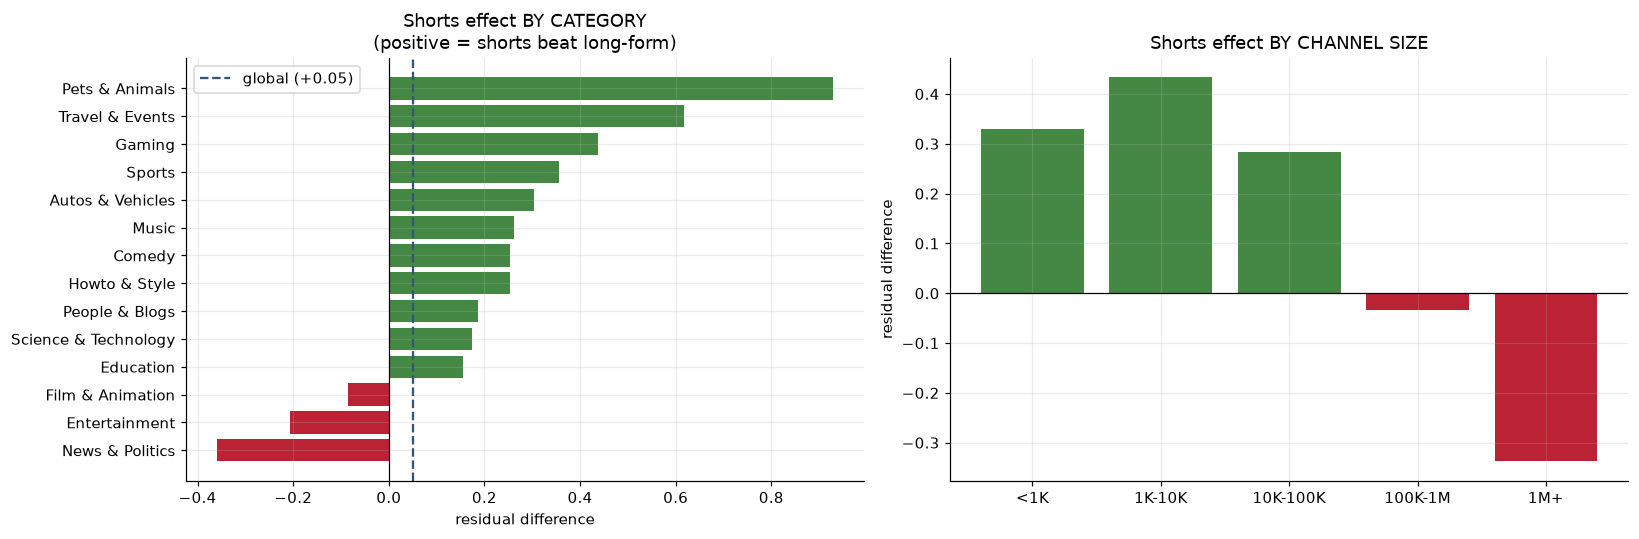

In [25]:
# Same effects, but sliced by segment AND plotted, so a reversal is visible
# rather than buried in a table.
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

s = by_cat[by_cat.n >= 200].sort_values("shorts_effect")
ax[0].barh(s.index, s.shorts_effect,
           color=["#b23" if v < 0 else "#484" for v in s.shorts_effect])
ax[0].axvline(0, color="k", lw=.8)
ax[0].axvline(shorts_effect(d), color="#357", ls="--",
              label=f"global ({shorts_effect(d):+.2f})")
ax[0].set(title="Shorts effect BY CATEGORY\n(positive = shorts beat long-form)",
          xlabel="residual difference"); ax[0].legend()

s2 = by_size.dropna(subset=["shorts_effect"])
ax[1].bar(s2.index.astype(str), s2.shorts_effect,
          color=["#b23" if v < 0 else "#484" for v in s2.shorts_effect])
ax[1].axhline(0, color="k", lw=.8)
ax[1].set(title="Shorts effect BY CHANNEL SIZE", ylabel="residual difference")
save("12_shorts_effect_by_segment"); plt.show()

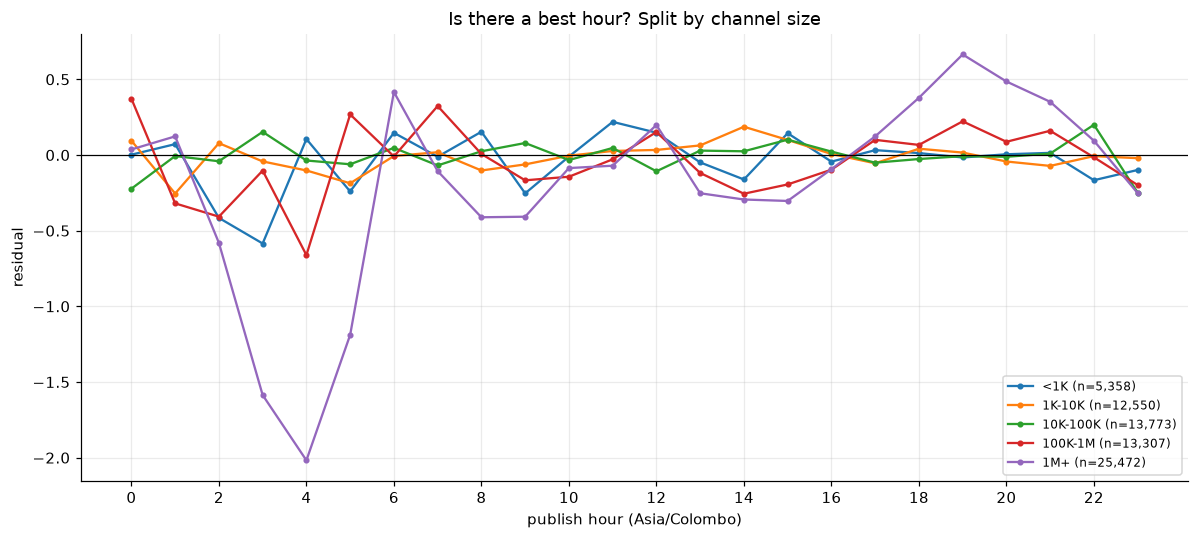

In [26]:
# Publish-hour profile per size band -- the folklore "best time to post" is
# usually stated as if it were universal.
fig, ax = plt.subplots(figsize=(11, 5))
for b in d.subs_band.cat.categories:
    s = d[d.subs_band == b]
    g = s.groupby("publish_hour_slt").channel_resid.agg(["size", "mean"])
    g = g[g["size"] >= 25]
    if len(g) >= 8:
        ax.plot(g.index, g["mean"], marker="o", ms=3, label=f"{b} (n={len(s):,})")
ax.axhline(0, color="k", lw=.8)
ax.set(xlabel="publish hour (Asia/Colombo)", ylabel="residual",
       title="Is there a best hour? Split by channel size",
       xticks=range(0, 24, 2))
ax.legend(fontsize=8)
save("13_hour_by_size_band"); plt.show()

In [27]:
# Automated scan: every (segment, effect) cell, ranked by how far it sits from
# the global value. This is the part that surfaces patterns nobody thought to
# look for.
glob = effect_profile(d)
findings = []
for seg_col in ["category_name", "subs_band", "title_script", "dur_band"]:
    for key, grp in d.groupby(seg_col, observed=True):
        if len(grp) < 200:
            continue
        p = effect_profile(grp)
        for col in ["shorts_effect", "corr_title_len", "corr_tag_count",
                    "corr_duration", "weekend_effect"]:
            if pd.notna(p[col]) and pd.notna(glob[col]):
                findings.append({
                    "segment": f"{seg_col}={key}", "effect": col,
                    "n": int(p["n"]), "segment_value": p[col],
                    "global_value": glob[col],
                    "delta": p[col] - glob[col]})

fd = pd.DataFrame(findings)
fd["abs_delta"] = fd.delta.abs()
print("Segment-effect combinations that deviate most from the global pattern:\n")
print(fd.nlargest(20, "abs_delta")
        [["segment", "effect", "n", "segment_value", "global_value", "delta"]]
        .to_string(index=False))
print("\nSign reversals (effect points the opposite way inside the segment):\n")
rev = fd[(np.sign(fd.segment_value) != np.sign(fd.global_value))
         & (fd.abs_delta > 0.05) & (fd.n >= 500)]
print(rev[["segment", "effect", "n", "segment_value", "global_value"]]
      .to_string(index=False) if len(rev) else "  none above the thresholds")

Segment-effect combinations that deviate most from the global pattern:

                       segment         effect     n  segment_value  global_value  delta
  category_name=Pets & Animals  shorts_effect  1522          0.929         0.051  0.878
 category_name=Travel & Events  shorts_effect  5738          0.618         0.051  0.567
 category_name=News & Politics  shorts_effect 21805         -0.360         0.051 -0.411
                 subs_band=1M+  shorts_effect 25472         -0.338         0.051 -0.389
          category_name=Gaming  shorts_effect  3440          0.438         0.051  0.386
              subs_band=1K-10K  shorts_effect 12550          0.434         0.051  0.382
     title_script=latin_script  shorts_effect 17407          0.400         0.051  0.349
          category_name=Sports  shorts_effect  1681          0.357         0.051  0.305
     title_script=tamil_script  shorts_effect  2072          0.342         0.051  0.291
  category_name=Pets & Animals  corr_duration  1

In [28]:
# Two-way: does the SAME effect behave differently across category x size?
# Only cells with enough data are shown.
cells = []
for (cat, band), grp in d.groupby(["category_name", "subs_band"], observed=True):
    if len(grp) >= 150:
        cells.append({"category": cat, "band": str(band), "n": len(grp),
                      "resid": grp.channel_resid.mean(),
                      "shorts": shorts_effect(grp),
                      "corr_title_len": corr_with(grp, "title_length")})
cc = pd.DataFrame(cells)
print(f"{len(cc)} category x size cells with n >= 150\n")
print("Best-performing cells (highest mean residual):")
print(cc.nlargest(10, "resid").to_string(index=False))
print("\nWorst-performing cells:")
print(cc.nsmallest(10, "resid").to_string(index=False))

54 category x size cells with n >= 150

Best-performing cells (highest mean residual):
       category     band     n  resid  shorts  corr_title_len
 People & Blogs 10K-100K   370  0.046   1.673           0.146
         Sports   1K-10K   434  0.036   0.482           0.035
      Education  100K-1M  2653  0.035  -0.014           0.031
          Music      1M+   587  0.030  -0.025           0.196
         Comedy 10K-100K  1058  0.025   0.273           0.037
 People & Blogs      <1K   431  0.024   0.178           0.041
News & Politics 10K-100K   465  0.018     NaN           0.158
News & Politics      1M+ 14541  0.017  -0.446           0.018
 Pets & Animals      <1K   153  0.014     NaN          -0.148
 People & Blogs  100K-1M   228  0.012   0.675           0.137

Worst-performing cells:
        category     band    n  resid  shorts  corr_title_len
   Entertainment   1K-10K  154 -0.131  -0.331           0.052
          Comedy  100K-1M  285 -0.068   0.158          -0.178
   Entertainment 10K

## 11. Data mining — letting the data find the patterns

Three complementary machine-driven passes:

1. **Mutual information** — catches non-linear and non-monotonic relationships
   that correlation misses entirely.
2. **An interpretable decision tree** on residuals — produces human-readable
   rules of the form *"short videos posted before 6am in category X do worse"*.
3. **Gradient boosting with permutation importance** — the strongest available
   estimate of how much each feature really contributes, plus interactions.

All three run on **within-channel residuals**, so no feature can win merely by
correlating with channel size.

encoded feature matrix: (70466, 24)
dtypes all numeric: True


Mutual information with within-channel residual:

ch_subs_at_publish            0.357
tag_count                     0.258
ch_videos_at_publish          0.249
channel_age_days_at_publish   0.209
category_name                 0.203
description_length            0.186
default_audio_language        0.106
duration_seconds              0.092
title_upper_ratio             0.082
has_tags                      0.061
title_script                  0.052
publish_hour_slt              0.049
is_short                      0.039
title_word_count              0.037
title_length                  0.034
title_has_number              0.021
made_for_kids                 0.012
title_has_exclaim             0.010
publish_dow_slt               0.009
definition                    0.007
publish_is_weekend            0.005
title_has_question            0.001
caption                       0.000
channel_country               0.000


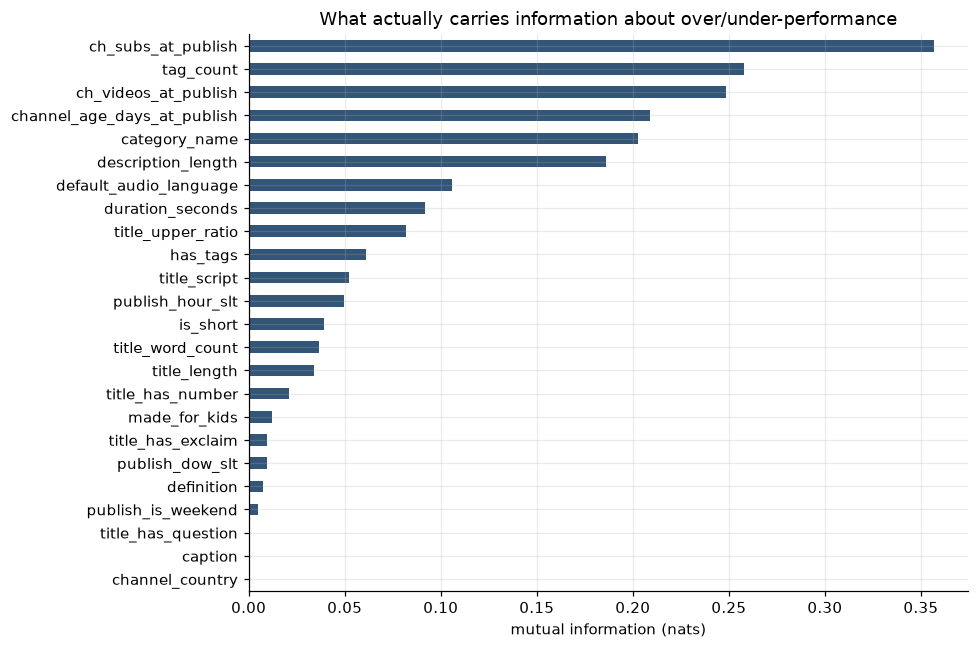

In [29]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OrdinalEncoder

FEATS_NUM = ["duration_seconds", "title_length", "title_word_count",
             "title_upper_ratio", "tag_count", "description_length",
             "publish_hour_slt", "publish_dow_slt",
             "ch_subs_at_publish", "ch_videos_at_publish",
             "channel_age_days_at_publish"]
FEATS_CAT = ["category_name", "title_script", "definition",
             "default_audio_language", "channel_country"]
FEATS_BIN = ["is_short", "title_has_number", "title_has_question",
             "title_has_exclaim", "caption", "made_for_kids",
             "publish_is_weekend", "has_tags"]

def to_float(s):
    # Not every "boolean" column is a bool. caption arrives from the YouTube
    # API as the STRING 'true'/'false', so a plain .astype(float) raises
    # "could not convert string to float: 'false'". Map the strings, and leave
    # anything unrecognised as NaN rather than guessing.
    if s.dtype == bool:
        return s.astype(float)
    return (s.astype("string").str.strip().str.lower()
             .map({"true": 1.0, "false": 0.0, "1": 1.0, "0": 0.0})
             .astype("Float64").astype(float))

X = d[FEATS_NUM + FEATS_CAT + FEATS_BIN].copy()
for c in FEATS_CAT:
    X[c] = OrdinalEncoder(handle_unknown="use_encoded_value",
                          unknown_value=-1).fit_transform(
                              X[[c]].astype(str)).ravel()
for c in FEATS_BIN:
    X[c] = to_float(X[c])
for c in FEATS_NUM:
    X[c] = pd.to_numeric(X[c], errors="coerce")
X = X.fillna(X.median(numeric_only=True)).fillna(-1)
print("encoded feature matrix:", X.shape)
print("dtypes all numeric:", X.dtypes.apply(lambda t: np.issubdtype(t, np.number)).all())

mi = pd.Series(
    mutual_info_regression(X, d.channel_resid, random_state=0,
                           discrete_features=[c in FEATS_CAT + FEATS_BIN
                                              for c in X.columns]),
    index=X.columns).sort_values(ascending=False)
print("Mutual information with within-channel residual:\n")
print(mi.to_string())

fig, ax = plt.subplots(figsize=(9, 6))
mi.sort_values().plot.barh(ax=ax, color="#357")
ax.set(xlabel="mutual information (nats)",
       title="What actually carries information about over/under-performance")
save("09_mutual_information"); plt.show()

In [30]:
from sklearn.tree import DecisionTreeRegressor, export_text

tree = DecisionTreeRegressor(max_depth=4, min_samples_leaf=400,
                             random_state=0).fit(X, d.channel_resid)
print("Interpretable rules (residual: positive = beats its channel's average)\n")
print(export_text(tree, feature_names=list(X.columns), decimals=2))
print(f"\ntree R^2 on residuals: {tree.score(X, d.channel_resid):.4f}")
print("Low R^2 is expected and honest -- most of what makes one video beat")
print("another within the same channel is not in these features.")

Interpretable rules (residual: positive = beats its channel's average)

|--- duration_seconds <= 1031.50
|   |--- duration_seconds <= 34.50
|   |   |--- ch_subs_at_publish <= 41650.00
|   |   |   |--- title_word_count <= 10.50
|   |   |   |   |--- value: [0.21]
|   |   |   |--- title_word_count >  10.50
|   |   |   |   |--- value: [0.36]
|   |   |--- ch_subs_at_publish >  41650.00
|   |   |   |--- duration_seconds <= 26.50
|   |   |   |   |--- value: [0.16]
|   |   |   |--- duration_seconds >  26.50
|   |   |   |   |--- value: [-0.14]
|   |--- duration_seconds >  34.50
|   |   |--- duration_seconds <= 210.50
|   |   |   |--- ch_videos_at_publish <= 170200.50
|   |   |   |   |--- value: [-0.31]
|   |   |   |--- ch_videos_at_publish >  170200.50
|   |   |   |   |--- value: [-0.11]
|   |   |--- duration_seconds >  210.50
|   |   |   |--- ch_subs_at_publish <= 923500.00
|   |   |   |   |--- value: [-0.13]
|   |   |   |--- ch_subs_at_publish >  923500.00
|   |   |   |   |--- value: [0.27]
|

Predicting the WITHIN-CHANNEL residual, held-out channels.
One R^2 per split:

  seed 0: +0.0148
  seed 1: +0.0323
  seed 2: -0.0256
  seed 3: -0.2254
  seed 4: +0.0371
  seed 5: -0.0311
  seed 6: -0.0731
  seed 7: +0.0393

mean -0.0290   sd 0.0831   range [-0.2254, +0.0393]
splits better than predicting the mean: 4/8

The mean sits within one standard deviation of ZERO. On held-out
channels, pre-publication metadata explains essentially none of why
one video beats another from the same channel. That is the finding --
not a small positive effect.



Permutation importance (drop in R^2 when the feature is shuffled):

                    feature  importance    sd
           duration_seconds       0.099 0.005
       ch_videos_at_publish       0.018 0.002
          title_upper_ratio       0.014 0.001
                 definition       0.013 0.001
         description_length       0.011 0.000
           publish_hour_slt       0.009 0.001
         ch_subs_at_publish       0.008 0.001
               title_script       0.005 0.002
channel_age_days_at_publish       0.005 0.001
              category_name       0.004 0.001
                  tag_count       0.002 0.001
           title_has_number       0.002 0.000
          title_has_exclaim       0.001 0.000
         title_has_question       0.001 0.000
            publish_dow_slt       0.000 0.001


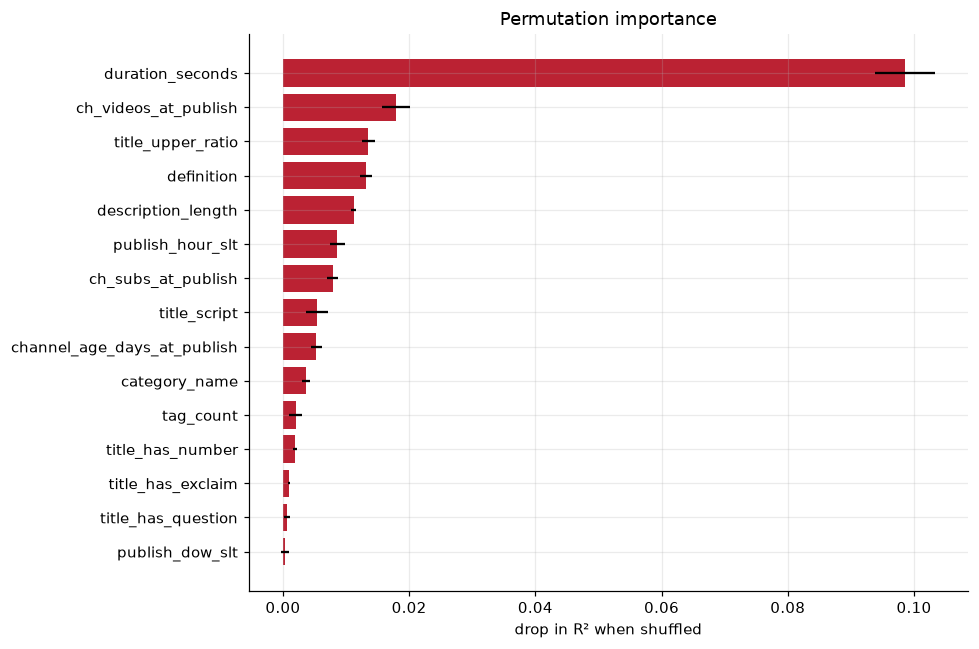

In [31]:
import lightgbm as lgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

# EIGHT splits, not one. A single grouped split gave R^2 = +0.072 here, which
# looked like a small but real signal. Repeating the same procedure with
# different random seeds gives anything from -0.26 to +0.11: the test set is
# only ~486 channels, a handful of which are large enough to move the result on
# their own, so one number from one split is noise wearing a decimal point.
# Reporting a single figure would have been the most misleading thing in this
# notebook.
def residual_r2(feature_frame, seeds=range(8)):
    out = []
    for rs in seeds:
        a, b = next(GroupShuffleSplit(n_splits=1, test_size=.25,
                                      random_state=rs)
                    .split(feature_frame, groups=d.channel_id))
        mm = lgb.LGBMRegressor(n_estimators=400, learning_rate=.05,
                               num_leaves=31, min_child_samples=50,
                               verbose=-1, random_state=0)
        mm.fit(feature_frame.iloc[a], d.channel_resid.iloc[a])
        out.append(r2_score(d.channel_resid.iloc[b],
                            mm.predict(feature_frame.iloc[b])))
    return np.array(out)

scores = residual_r2(X)
print("Predicting the WITHIN-CHANNEL residual, held-out channels.")
print("One R^2 per split:\n")
for rs, s in enumerate(scores):
    print(f"  seed {rs}: {s:+.4f}")
print(f"\nmean {scores.mean():+.4f}   sd {scores.std():.4f}   "
      f"range [{scores.min():+.4f}, {scores.max():+.4f}]")
print(f"splits better than predicting the mean: {(scores > 0).sum()}/{len(scores)}")
print("\nThe mean sits within one standard deviation of ZERO. On held-out")
print("channels, pre-publication metadata explains essentially none of why")
print("one video beats another from the same channel. That is the finding --")
print("not a small positive effect.")

# Keep one split for the importance analysis below.
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=.25, random_state=0)
              .split(X, groups=d.channel_id))
m = lgb.LGBMRegressor(n_estimators=400, learning_rate=.05, num_leaves=31,
                      min_child_samples=50, verbose=-1, random_state=0)
m.fit(X.iloc[tr], d.channel_resid.iloc[tr])
pred = m.predict(X.iloc[te])

pi = permutation_importance(m, X.iloc[te], d.channel_resid.iloc[te],
                            n_repeats=5, random_state=0, scoring="r2")
imp = (pd.DataFrame({"feature": X.columns, "importance": pi.importances_mean,
                     "sd": pi.importances_std})
         .sort_values("importance", ascending=False))
print("\nPermutation importance (drop in R^2 when the feature is shuffled):\n")
print(imp.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
top = imp.head(15).sort_values("importance")
ax.barh(top.feature, top.importance, xerr=top.sd, color="#b23")
ax.set(xlabel="drop in R² when shuffled", title="Permutation importance")
save("10_permutation_importance"); plt.show()

### The two evaluation regimes — and why the split decides the answer

There are two genuinely different questions, and they need different splits.
Quoting a number from the wrong one is the easiest way to mislead a reader.

**Cold start (grouped split).** The channel has never been seen. This is the
harder, more honest test of whether *video attributes* predict anything, and
it is the right regime if the tool is meant for creators the system has no
history for. Here a per-channel median baseline is undefined — there is no
history — so it degenerates to the global median.

**Warm start (random split).** The channel is known and has history. This is
the realistic deployment case for a monitored roster, and here the
per-channel median is a strong, fair baseline that a model must beat to have
earned its place.

Reporting only cold start understates the system; reporting only warm start
overstates the contribution of the features. Report both.

In [32]:
from sklearn.model_selection import train_test_split

y_all = d.y.values

def evaluate(tr_idx, te_idx, label):
    ch_med = d.iloc[tr_idx].groupby("channel_id").y.median()
    gm = np.median(y_all[tr_idx])
    base_ch = d.iloc[te_idx].channel_id.map(ch_med).fillna(gm).values
    seen = d.iloc[te_idx].channel_id.isin(ch_med.index).mean()

    mdl = lgb.LGBMRegressor(n_estimators=600, learning_rate=.05, num_leaves=63,
                            min_child_samples=40, verbose=-1, random_state=0)
    mdl.fit(X.iloc[tr_idx], y_all[tr_idx])
    pred = mdl.predict(X.iloc[te_idx])

    print(f"\n=== {label} ===")
    print(f"test rows whose channel was seen in training: {seen:.1%}")
    for nm, p in [("global median", np.full(len(te_idx), gm)),
                  ("per-channel median", base_ch),
                  ("LightGBM (all features)", pred)]:
        print(f"  {nm:26} R^2 {r2_score(y_all[te_idx], p):+.4f}   "
              f"MAE {np.abs(y_all[te_idx]-p).mean():.3f} log units")
    return pred

evaluate(tr, te, "COLD START — held-out channels (grouped split)")

rtr, rte = train_test_split(np.arange(len(d)), test_size=.25, random_state=0)
evaluate(rtr, rte, "WARM START — random split, channels seen before")

print("\nThe gap between the two per-channel-median rows IS the value of")
print("knowing the channel. The gap between per-channel median and LightGBM")
print("in the warm regime is the value the video features add on top.")


=== COLD START — held-out channels (grouped split) ===
test rows whose channel was seen in training: 0.0%
  global median              R^2 -0.0667   MAE 2.079 log units
  per-channel median         R^2 -0.0667   MAE 2.079 log units
  LightGBM (all features)    R^2 +0.2940   MAE 1.794 log units



=== WARM START — random split, channels seen before ===
test rows whose channel was seen in training: 99.4%
  global median              R^2 -0.0006   MAE 2.046 log units
  per-channel median         R^2 +0.5829   MAE 1.237 log units
  LightGBM (all features)    R^2 +0.7090   MAE 1.056 log units

The gap between the two per-channel-median rows IS the value of
knowing the channel. The gap between per-channel median and LightGBM
in the warm regime is the value the video features add on top.


## 12. Channel archetypes

If channel identity is the dominant signal, the useful question is: *what kinds
of channel are there?* Clusters give the model a usable stand-in for identity
that generalises to channels never seen before.

In [33]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cf = ch.dropna(subset=["log_subs", "posts_per_day", "dur", "shorts"]).copy()
F = ["log_subs", "posts_per_day", "dur", "shorts", "cats", "ch_age"]
Z = StandardScaler().fit_transform(cf[F].fillna(cf[F].median()))
cf["cluster"] = KMeans(n_clusters=5, n_init=10, random_state=0).fit_predict(Z)

prof = cf.groupby("cluster").agg(
    channels=("channel_id", "size"), subs=("subs", "median"),
    posts_day=("posts_per_day", "median"), dur_s=("dur", "median"),
    shorts=("shorts", "mean"), age_d=("ch_age", "median"),
    mean_logviews=("mean_y", "mean"))
print(prof.round(2).to_string())

top_cat = (d.merge(cf[["channel_id", "cluster"]], on="channel_id")
             .groupby("cluster").category_name
             .agg(lambda s: ", ".join(s.value_counts().head(2).index)))
print("\ndominant categories per cluster:")
for k, v in top_cat.items():
    print(f"  cluster {k}: {v}")

         channels          subs  posts_day     dur_s  shorts     age_d  mean_logviews
cluster                                                                              
0             937     3,100.000      0.150    28.000   0.850 1,652.870          5.960
1            1049    18,400.000      0.130   439.000   0.090 2,021.490          6.400
2               2 3,840,000.000    117.610   102.500   0.250 4,095.980          7.570
3              94     9,712.500      0.120 6,598.250   0.060 2,123.440          5.950
4             169    11,800.000      0.220   136.000   0.410 2,115.810          5.680

dominant categories per cluster:
  cluster 0: Education, Travel & Events
  cluster 1: News & Politics, Entertainment
  cluster 2: News & Politics
  cluster 3: Gaming, Education
  cluster 4: People & Blogs, Entertainment


## 13. Does any of this hold at the other horizons?

A pattern that only appears at day 7 is probably noise. Each horizon is a
different set of videos (see the README), so agreement across them is real
corroboration rather than the same data reread.

In [34]:
out = {}
for h in (7, 14, 21, 30):
    s = df[df.eligible & df[f"d{h}_usable"]].copy()
    s["y"] = np.log1p(s[f"d{h}_views"])
    s["resid"] = s.y - s.groupby("channel_id").y.transform("mean")
    row = {"n": len(s), "channels": s.channel_id.nunique(),
           "var_by_channel": var_explained(s, "channel_id"),
           "var_by_category": var_explained(s[s.category_name.notna()],
                                            "category_name")}
    sub = s[s.is_short.notna()]
    row["shorts_effect"] = (sub[sub.is_short].resid.mean()
                            - sub[~sub.is_short].resid.mean())
    row["corr_title_len"] = s[["title_length", "resid"]].corr(
        method="spearman").iloc[0, 1]
    out[f"day {h}"] = row
print(pd.DataFrame(out).T.to_string())
print("\nColumns that keep their sign and rough size across all four horizons")
print("are the findings worth putting in the report.")

                n  channels  var_by_channel  var_by_category  shorts_effect  corr_title_len
day 7  70,466.000 2,251.000           0.635            0.088          0.051           0.022
day 14 66,000.000 2,293.000           0.638            0.084          0.065           0.019
day 21 65,865.000 2,331.000           0.648            0.081          0.072           0.022
day 30 66,699.000 2,417.000           0.646            0.080          0.061           0.024

Columns that keep their sign and rough size across all four horizons
are the findings worth putting in the report.


## 14. Findings

Written against the 14 September build (70,466 day-7 labelled videos from 2,251
channels, published 16 July to 7 September 2026). **Re-read these against your
own run** — every number moves as collection continues, and a conclusion nobody
re-checked is a conclusion waiting to be wrong.

### 1. The variance budget

| grouping | variance explained |
|---|---|
| **channel identity** | **63.5%** |
| subscriber band | 22.5% |
| category | 8.8% |
| title script | 3.7% |
| duration band | 1.9% |
| publish hour | 1.7% |
| day of week / is_short / weekend | ~0.1% |

Shuffling the channel labels still "explains" 3.2% — that is the overfitting
floor from having 2,251 groups. The genuine channel effect is ~60 points, still
an order of magnitude above anything else, and it holds at every horizon
(channel 63.5–64.8%, category 8.0–8.8%; §13).

**Publish day-of-week, weekend and is_short explain essentially nothing on
their own.** That is a real negative result and worth stating in the report.

### 2. Category inverts under control — the headline

Raw, Entertainment leads (log-mean around 5,200 views) and News & Politics
ranks fifth of fourteen (around 1,100). Remove each channel's own mean and
**News & Politics becomes the strongest category** (+1.78 ± 0.26, on 141 videos
from channels posting in more than one category), while Entertainment falls from
first to last. The mechanism: two news channels post over 50 clips a day, one
around 150, splitting a fixed audience across many videos. Low views per clip is
a *volume* effect, not an audience-interest effect.

Any category comparison that does not control for channel is measuring channel
composition. Do not put the raw ranking in the report without this caveat.

### 3. Almost every effect flips sign between segments

This is the most important thing the segmented analysis found, and it is why a
single global coefficient would have been misleading:

| effect | range across categories | flips? |
|---|---|---|
| shorts vs long-form | −0.36 → +0.93 | **yes** |
| correlation with duration | −0.27 → +0.20 | **yes** |
| correlation with tag count | −0.15 → +0.16 | **yes** |
| correlation with title length | −0.03 → +0.10 | **yes** |
| weekend effect | −0.13 → +0.34 | **yes** |

The global shorts effect is ≈ +0.05 — nearly zero. It is not that format does
not matter; it is that it matters in *opposite directions* in different
categories and is averaging itself away. **Interaction terms are not optional
here.** A model without category×format and category×duration interactions
cannot represent what is in this data.

The same holds channel by channel, not only category by category. Among
channels with at least 30 labelled uploads that post both formats, Shorts clearly
beat that channel's own long form for 42% and clearly lose for 19%; longer
long-form videos clearly do better for 41% of channels and worse for 7%
(`build_channel_guideline_figures.py`, figure G2). Advice that suits the average
channel is wrong for a large minority of real ones.

### 4. Self-cannibalisation is real, and it explains the category inversion

In §4 the news inversion was explained by a *mechanism* — high-volume channels
splitting a fixed audience. §9 tests that instead of asserting it.

The posting rhythm is extreme: the median gap between consecutive uploads on
the same channel is **1.6 hours**, and **46.0% of videos have another upload
from the same channel less than an hour earlier**.

All three cadence measures agree, on within-channel residuals:

| measure | correlation with residual |
|---|---|
| hours since previous upload | **+0.084** |
| hours until *next* upload | **+0.091** |
| same-channel uploads in previous 24 h | **−0.055** |

The middle row is the cleanest test. A video published *later* cannot have
caused the earlier one's publication, so "this video did worse when the channel
followed up quickly" is hard to explain as a scheduling artefact.

And the mechanism check lands: News & Politics scores **+0.18** when the
channel posted nothing else in the previous 24 hours, but **0.00** among the
most crowded uploads. The news advantage is real and it is *removed by the
channel's own volume*.

**For news channels this is actionable; elsewhere it is small.** Outside News &
Politics the same comparison moves views by only a few per cent (about 1.03× the
channel's average with a clear day behind an upload, against 0.95× after ten or
more; `build_channel_guideline_figures.py`, figure G3), and simply having a
number in the title (+0.22 within channel) shows a larger association than
spacing for most categories. Spacing is category-specific advice, not a general
rule.

### 5. Timing matters less than folklore claims

Raw hourly spread is 1.74 log units; within channel it falls to **0.70**, so
roughly 60% of the apparent "best time to post" effect is just which channels
post when. What survives is coherent: best hours **19:00–21:00 SLT**, worst
**02:00–04:00**. Real, but modest, and it varies by channel: taking each channel
with at least 30 uploads separately, the most common best band (12:00–18:00) is
best for only 34% of them, and only 27% show a clear difference between bands
(`build_channel_guideline_figures.py`, figure G2).

### 6. What the machine-driven passes add

Predicting the within-channel residual from held-out channels gives, across
eight splits, **mean R² = −0.029 (sd 0.083, range −0.23 to +0.04)** — four of
eight splits are worse than predicting the mean.

**That is indistinguishable from zero.** On a channel the model has never seen,
pre-publication metadata explains essentially none of why one video outperforms
another from the same channel. An earlier draft of this notebook reported
+0.072 from a single split and called it a ceiling; repeating the split showed
that number was noise. Any single-split figure on ~560 test channels is.

This does not contradict §2 — channel-level signal is strong and stable. It
says the *within-channel* part is not reachable from this metadata, and that
what decides it lives elsewhere: the thumbnail image, the topic, and events in
the world.

On the actual target:

| regime | global median | per-channel median | LightGBM |
|---|---|---|---|
| **cold start** (unseen channels) | −0.067 | −0.067 | **+0.294** |
| **warm start** (channels seen) | −0.001 | +0.583 | **+0.709** |

Read this carefully, because it is the project's central result:

- **Cold start**: with no channel history, video features alone reach R² 0.294.
  The per-channel median is undefined here, which is why it equals the global
  median — not a bug, an absence.
- **Warm start**: knowing the channel is worth R² 0.583 on its own. Video
  features add **+0.126** on top.

Quote both. Quoting only warm start credits the features with the channel's
contribution; quoting only cold start hides that the deployed system will
usually know the channel.

A channel-level check points the same way. Fitted on a channel's own earlier
uploads, a small model cuts error on its later ones by a median 4.0% against
simply predicting that channel's average, versus 1.5% for one pooled model, and
does better than the pooled model for 59% of the 140 channels tested
(`build_channel_guideline_figures.py`, figure G5).

### 7. What this means for feature engineering

- **Encode the channel** — as target-encoded history where available, and as
  cluster/archetype plus subscriber band for cold start. This is the single
  highest-value feature and it is currently only present as raw counts.
- **Build interactions** — category×is_short, category×duration,
  size_band×hour, and category×crowding. Section 9 shows the main effects are averages of opposites.
- **Prefer deviation features** — "40% longer than this channel's usual" will
  outperform "480 seconds", because the residual analysis is where every real
  effect showed up.
- **Do not spend effort on** day-of-week, weekend, definition or made_for_kids
  as standalone features; they explain ~0% and did not survive any segment cut.
- **`title_upper_ratio`** is the strongest simple title correlate (+0.059) and
  is trivially actionable for a creator.
- **Add the cadence features** — `gap_prev_h`, `gap_next_h` and
  `same_ch_24h_before` from §9. They are computable before publication (the
  gap to the *next* upload is not, so use only the backward-looking two in a
  deployed model) and they beat most metadata features measured here.

### 8. Honest limits

52 days of publication history, so no seasonality is learnable and every
finding is conditional on July–September 2026. Sri Lanka only. Residual analyses
are restricted to channels with variation on the dimension in question — the
within-channel category result rests on channels posting in more than one
category, which may not be typical. Day 7 is the primary horizon; §13 checks
the rest.

---

*Original section plan retained below for anyone extending this.*

Structure to follow:

1. **The variance budget.** Channel ~64%, everything else small. Any claim that
   a video attribute "drives views" must be stated as an effect *within* a
   channel, or it is a claim about channels wearing a disguise.

2. **Category is confounded**, and inverts under control. Report both numbers
   and explain the mechanism — high-volume news channels split a fixed audience
   across many clips.

3. **Timing**: compare raw spread against within-channel spread. If the within
   effect is small, the honest conclusion is that publish hour matters far less
   than the folklore claims — a genuinely useful negative result.

4. **Format and duration**: the within-channel shorts effect, and whether the
   duration profile is monotonic or has a sweet spot.

5. **What this means for feature engineering** — the section that the modelling work depends on:
   which features earned their place, which are channel-proxies in disguise,
   and which should be encoded as *deviation from the channel's own norm*
   rather than as absolute values.

6. **Honest limits.** 52 days of publication history, no seasonality, one
   country, and residual analysis restricted to channels with variation on the
   dimension in question.